In [44]:
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(2017)
n_attrib = 2
N = 1_000

X = np.random.randn(N, n_attrib)
y = ((X[:, 0]**2 + X[:, 1]**2 + np.random.randn(N) * 1) > 2.3).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2016)


In [46]:
y

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,

In [47]:
from sklearn.naive_bayes import GaussianNB

# instancia e treina o classificador
clf = GaussianNB()
clf.fit(X_train, y_train)

# médias e variâncias aprendidas por classe
print(clf.theta_)   # médias
print(clf.var_)     # variâncias


[[-0.00531441  0.03454452]
 [-0.14050795  0.06736628]]
[[0.51161938 0.51164244]
 [2.04507586 1.85178232]]


In [48]:
# probabilidades por classe
probs = clf.predict_proba(X_test)
print(probs[:5].round(3))

# rótulo previsto (classe mais provável)
y_pred = clf.predict(X_test)
print(y_pred[:5])


[[0.687 0.313]
 [0.853 0.147]
 [0.826 0.174]
 [0.502 0.498]
 [0.029 0.971]]
[0 0 0 0 1]


In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)
print(cm)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.2%}")


[[189  10]
 [ 32  69]]
Acurácia: 86.00%


Gráfico salvo em decision_boundary.png


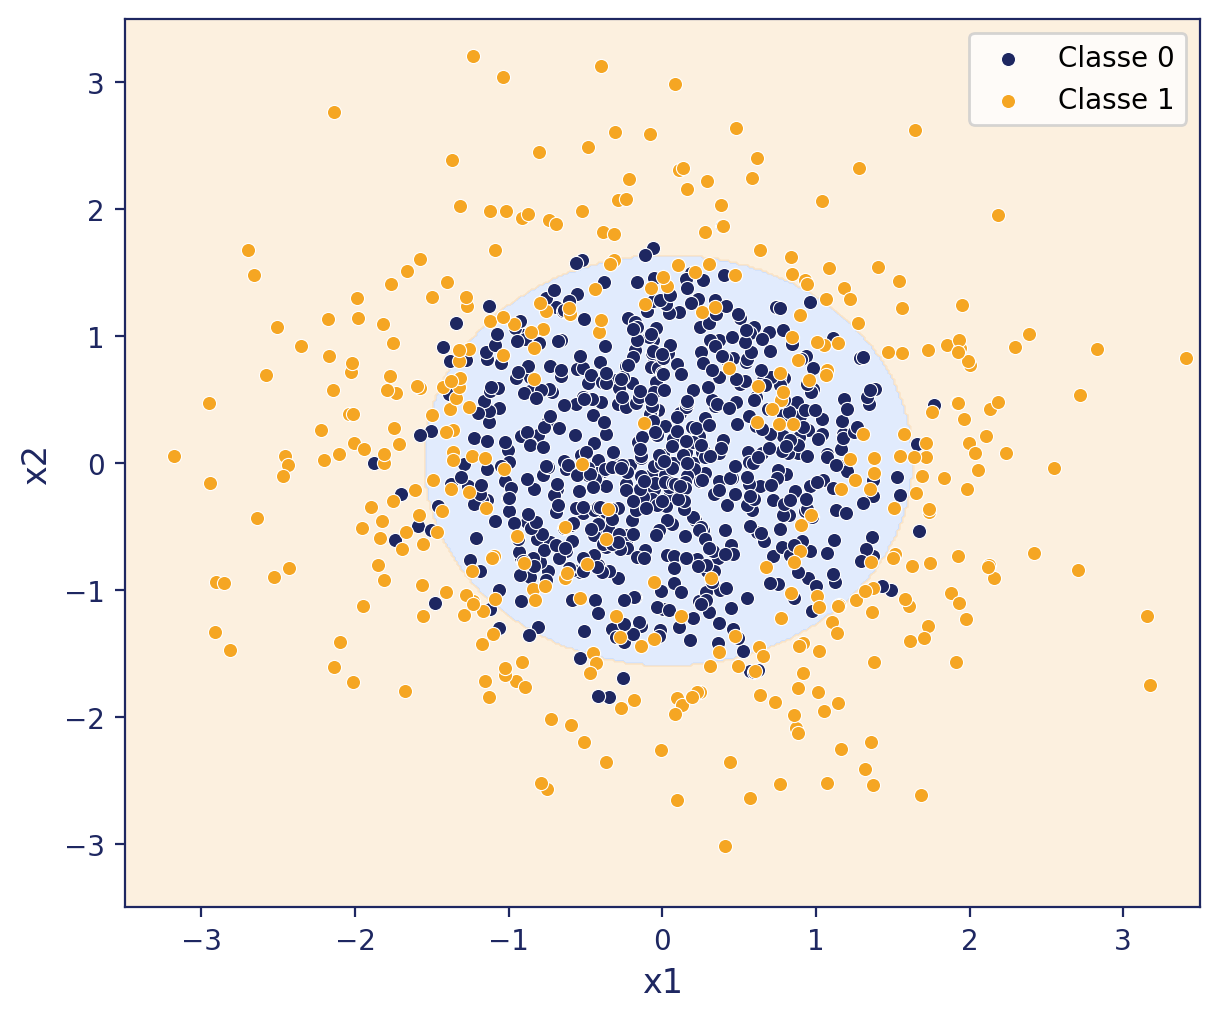

In [50]:

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ---------------------------------------------------------
# 3. Cria uma malha (grid) cobrindo o espaço de x1/x2 e
#    classifica cada ponto da malha -> isso desenha as regiões
# ---------------------------------------------------------
xx, yy = np.meshgrid(
    np.linspace(-3.5, 3.5, 400),
    np.linspace(-3.5, 3.5, 400),
)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
 
# ---------------------------------------------------------
# 4. Estilo (paleta FGV EESP: navy / azul claro / âmbar)
# ---------------------------------------------------------
navy = "#1E2761"
lightblue = "#CADCFC"
amber = "#F5A623"
 
fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=200)
fig.patch.set_alpha(0)       # fundo da figura transparente
ax.set_facecolor("none")     # fundo dos eixos transparente
 
# regiões de decisão
cmap_bg = ListedColormap([lightblue, "#FBE4C6"])
ax.contourf(xx, yy, Z, alpha=0.55, cmap=cmap_bg)
 
# pontos observados, coloridos pela classe verdadeira
ax.scatter(X[y == 0, 0], X[y == 0, 1], c=navy, s=26,
           label="Classe 0", edgecolor="white", linewidth=0.4)
ax.scatter(X[y == 1, 0], X[y == 1, 1], c=amber, s=26,
           label="Classe 1", edgecolor="white", linewidth=0.4)
 
ax.set_xlabel("x1", fontsize=12, color=navy)
ax.set_ylabel("x2", fontsize=12, color=navy)
ax.tick_params(colors=navy, labelsize=10)
for spine in ax.spines.values():
    spine.set_color(navy)
ax.legend(loc="upper right", frameon=True, fontsize=10)
 
plt.tight_layout()
plt.savefig("decision_boundary.png", transparent=True)
print("Gráfico salvo em decision_boundary.png")
 